## PROJETO AVALIATIVO - PIPELINE PREDITIVO

In [1]:
#Importação da base de dados
import pandas as pd

df_bruto = pd.read_csv("data/manutencao_preditiva.csv")

df_bruto.head()


,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


FASE 1 - ANÁLISE EXPLORATÓRIA DOS DADOS

In [2]:
from src.analysis import inspecionar_dados
inspecionar_dados(df_bruto)


=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (10000, 14)

Colunas: ['udi', 'id_produto', 'tipo', 'temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'falha_maquina', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']

Tipos de dados:
udi                          int64
id_produto                  object
tipo                        object
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object

Valores nulos por coluna:
udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocid

## Geração de gráficos analíticos
Gráfico 1 - Histograma das variáveis preditores

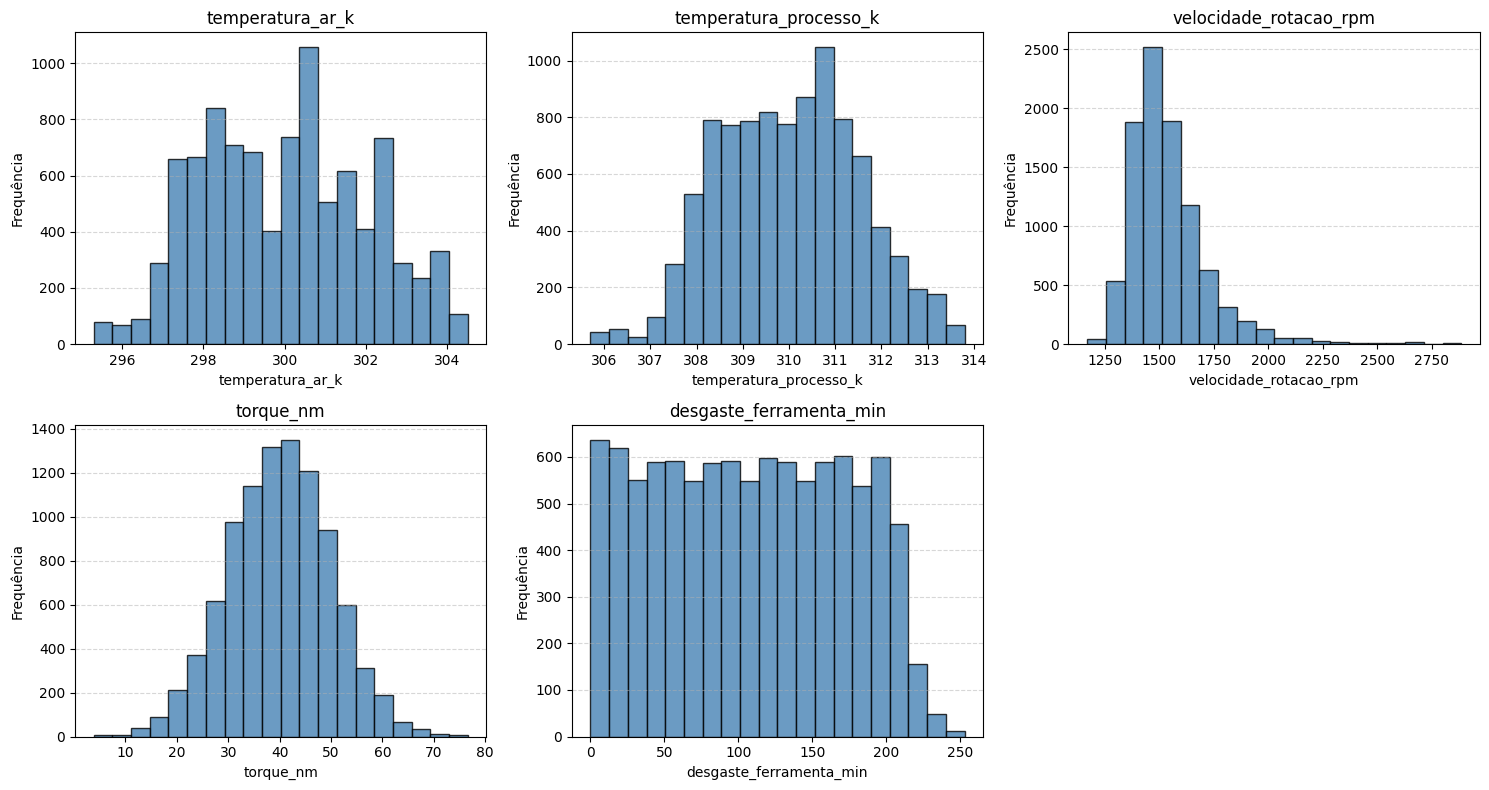

In [6]:
variaveis_numericas = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min"
]

from src.visualization import gerar_histogramas
gerar_histogramas(df_bruto, variaveis_numericas)

Gráfico 2 - Gráfico de barras - taxa de desbalanceamento da variável alvo

c:\Users\eduarda.echer\pipeline-preditivo\src\visualization.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=contagem.index, y=contagem.values, palette=cores)
c:\Users\eduarda.echer\pipeline-preditivo\src\visualization.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


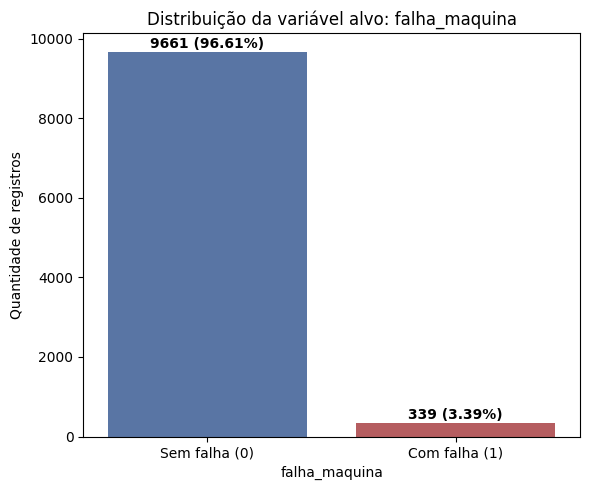

falha_maquina
0    9661
1     339
Name: count, dtype: int64
falha_maquina
0    96.61
1     3.39
Name: proportion, dtype: float64


In [7]:
from src.visualization import gerar_grafico_distribuicao_alvo

gerar_grafico_distribuicao_alvo(
    df_bruto, 
    coluna_alvo='falha_maquina', 
    labels=['Sem falha (0)', 'Com falha (1)']
)

Gráfico 3 - Mapa de calor - correlação de Pearson entre variáveis

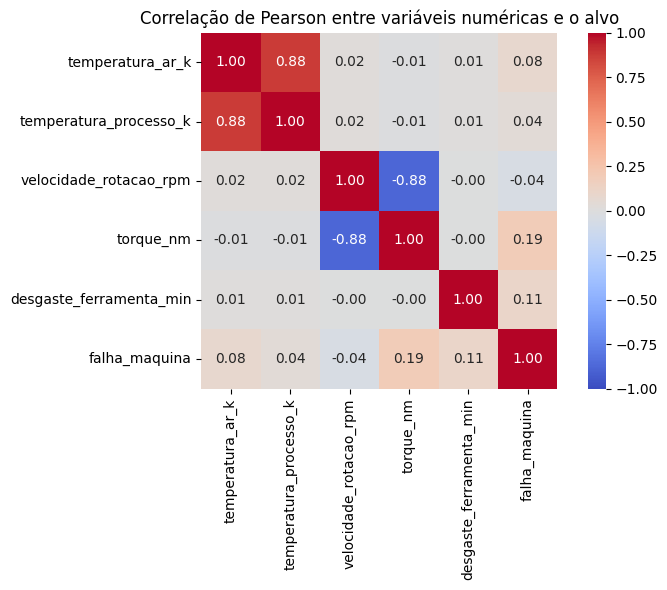

In [8]:
from src.visualization import gerar_heatmap_correlacao

colunas_correlacao = variaveis_numericas + ['falha_maquina']

matriz_corr = gerar_heatmap_correlacao(
    df_bruto, 
    colunas=colunas_correlacao, 
    titulo="Correlação de Pearson entre variáveis numéricas e o alvo"
)

## Conclusões sobre a Análise Exploratória de Dados

- **Dimensões e tipos**: o dataset possui 10.000 registros e 14 colunas, sendo:
  - 5 variáveis numéricas consideradas relevantes para a modelagem (temperatura_ar_k, temperatura_processo_k, velocidade_rotacao_rpm, torque_nm, desgaste_ferramenta_min),
  - uma variável categórica (tipo do produto: L, M, H) e,
  - a variável alvo em formato binário falha_maquina.
  - As colunas udi e id_produto são colunas identificadoras e serão descartadas da modelagem. 
  - As colunas falha_twf, falha_hdf, falha_pwf, falha_osf e falha_rnf indicam o tipo específico de falha e serão excluídas das features, pois não tem utilidade para essa análise.
- **Resumo estatístico**: as variáveis de temperatura têm baixa dispersão (desvio-padrão ~2K), enquanto torque_nm e velocidade_rotacao_rpm apresentam maior variabilidade. O desgaste_ferramenta_min varia de 0 a aproximadamente 253 minutos, sugerindo diferentes estágios de vida útil da ferramenta no momento da medição.
- **Histogramas**: temperatura_ar_k, temperatura_processo_k, torque_nm e desgaste_ferramenta_min seguem distribuições próximas da normal (simétricas). Já velocidade_rotacao_rpm apresenta assimetria à direita, o que já indica presença de outliers e reforça a necessidade de tratamento na Fase 2 e de escalonamento (StandardScaler) antes de usar modelos sensíveis à escala, como o KNN.
- **Desbalanceamento do alvo**: apenas aproximadamente 3,4% dos registros (339 de 10.000) representam falha de máquina. Esse forte desbalanceamento indica que uma acurácia simples pode ser enganosa. Isso justifica a aplicação de reamostragem (SMOTE) exclusivamente no conjunto de treino na Fase 4, para evitar que o modelo ignore a classe minoritária.
- **Correlação de Pearson**: torque_nm e velocidade_rotacao_rpm apresentam correlação negativa forte entre si (fisicamente esperado, já que potência é aproximadamente constante). Em relação ao alvo, torque_nm e desgaste_ferramenta_min mostram as correlações lineares mais relevantes com falha_maquina, embora nenhuma variável isolada explique a falha sozinha, podendo sugerir que a relação é não linear, favorecendo modelos mais complexos (como a Árvore de Decisão) ou métodos baseados em distância (KNN).

Esses padrões direcionam a estratégia de modelagem: (1) tratar outliers e nulos antes de treinar; (2) criar uma variável combinada (potencia) que capture a relação física entre torque e rotação; (3) balancear apenas o treino; (4) escalonar variáveis apenas para o KNN; e (5) comparar KNN e Árvore de Decisão controlando o overfitting via n_neighbors e max_depth.